In [1]:
pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import time

Part 1


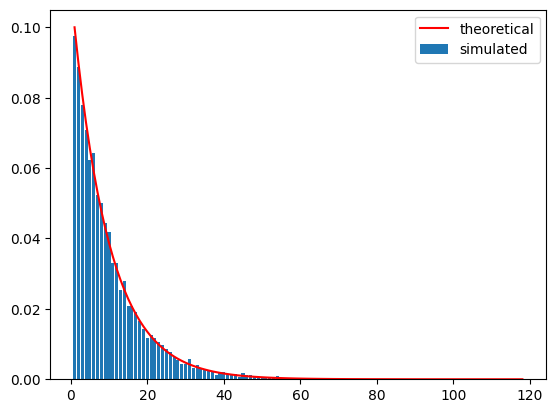

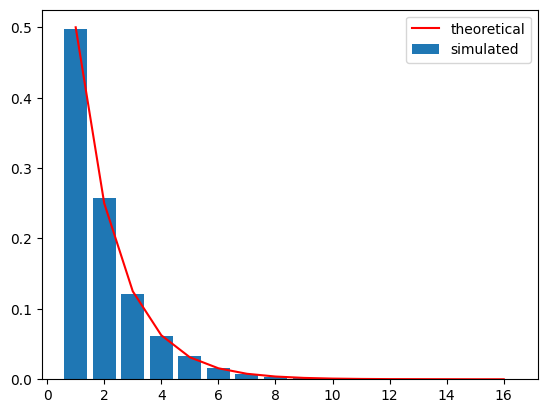

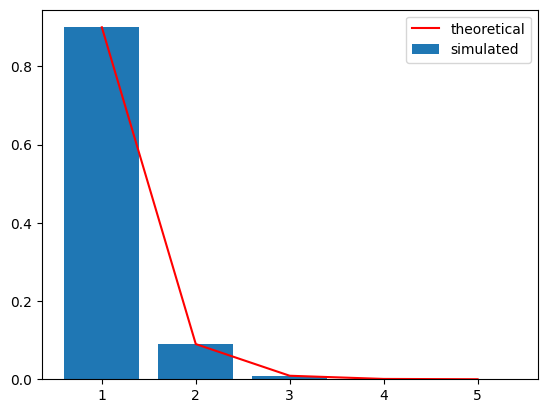

In [13]:
def sample_from_geometric(p: float):
    U = random.random()
    return math.floor(math.log(U) / math.log(1 - p)) + 1

def compare_simulated_vs_theoretical(n: int, p: float):
    arr = np.zeros(n)
    for i in range(n):
       arr[i] = sample_from_geometric(p)

    values, counts = np.unique(arr, return_counts=True)

    plt.bar(values, counts/ n, label="simulated")
    plt.plot(values, (1 - p)**(values - 1) * p, '-', color="red", label="theoretical")
    plt.legend()
    plt.show()

n: int = 10000
compare_simulated_vs_theoretical(n, 0.1)
compare_simulated_vs_theoretical(n, 0.5)
compare_simulated_vs_theoretical(n, 0.9)


Part 2

In [ ]:
P = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])

def sample_direct(P, P_cum_sum):
    U = random.random()

    for i in range(len(P_cum_sum)):
        if U <= P_cum_sum[i]:
            return i + 1
    return len(P_cum_sum)

def sample_rejection(P):
    c = np.max(P)
    while True:
        i = math.floor(len(P) * random.random())

        U2 = random.random()
        if U2 <= P[i] / c:
            return i + 1

def build_alias_tables(P):
    k = len(P)
    q = P * k                       
    prob = np.zeros(k)              
    alias = np.zeros(k, dtype=int)  

    small = [i for i in range(k) if q[i] < 1]    
    large = [i for i in range(k) if q[i] >= 1]   

    while small and large:
        s = small.pop()             
        l = large.pop()             
        prob[s] = q[s]              
        alias[s] = l                
        q[l] = q[l] - (1 - q[s])    
        if q[l] < 1:
            small.append(l)         
        else:
            large.append(l)         

    for i in large + small:
        prob[i] = 1                 

    return prob, alias

def sample_alias(prob, alias, k):
    i = math.floor(k * random.random())   
    if random.random() < prob[i]:         
        return i + 1                      
    else:
        return alias[i] + 1 


Direct time: 0.003833291004411876
Rejection time: 0.015456542023457587
Alias time: 0.002652458002557978


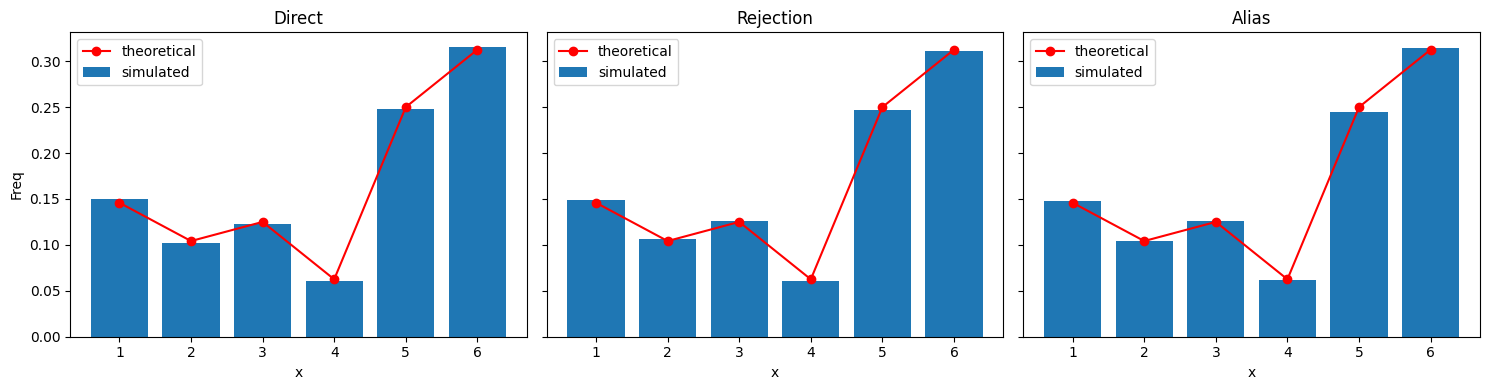

In [15]:
n = 10000
values = np.arange(1, len(P) + 1)   # [1,2,3,4,5,6]

t0 = time.perf_counter()
P_cum_sum = np.cumsum(P)
samples_direct = np.array([sample_direct(P, P_cum_sum) for _ in range(n)])
t1 = time.perf_counter()
print("Direct time:", t1 - t0)

t0 = time.perf_counter()
samples_rejection = np.array([sample_rejection(P) for _ in range(n)])
t1 = time.perf_counter()
print("Rejection time:", t1 - t0)

t0 = time.perf_counter()
prob, alias = build_alias_tables(P)
samples_alias = np.array([sample_alias(prob, alias, len(P)) for _ in range(n)])
t1 = time.perf_counter()
print("Alias time:", t1 - t0)

samples = [samples_direct, samples_rejection, samples_alias]
titles = ["Direct", "Rejection", "Alias"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, s, title in zip(axes, samples, titles):
    vals, counts = np.unique(s, return_counts=True)
    ax.bar(vals, counts / n, label="simulated")
    ax.plot(values, P, 'o-', color="red", label="theoretical")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.legend()
axes[0].set_ylabel("Freq")
plt.tight_layout()
plt.show()

def simulate(method, n):
    if method == "Crude":
        return np.array([sample_direct(P, P_cum_sum) for _ in range(n)])
    if method == "Rejection":
        return np.array([sample_rejection(P) for _ in range(n)])
    if method == "Alias":
        return np.array([sample_alias(prob, alias, len(P)) for _ in range(n)])

In [18]:
n_sims = 100
n_samples = 1000
z = 1.96

mu_theo = np.sum(values * P)
sigma_theo = np.sqrt(np.sum(values**2 * P) - mu_theo**2)
print(f"Theoretical mean = {mu_theo:.3f}, std = {sigma_theo:.3f}")

for method in ["Crude", "Rejection", "Alias"]:
    means = np.empty(n_sims)
    stds  = np.empty(n_sims)

    t0 = time.perf_counter()
    for s in range(n_sims):
        sample       = simulate(method, n_samples)
        means[s]     = sample.mean()
        stds[s]      = sample.std(ddof=1)
    t1 = time.perf_counter()

    m, se_m = means.mean(), means.std(ddof=1) / np.sqrt(n_sims)
    s, se_s = stds.mean(),  stds.std(ddof=1)  / np.sqrt(n_sims)

    sample   = simulate(method, n_samples)
    observed = np.array([np.sum(sample == v) for v in values])
    chi2_stat, chi2_p = stats.chisquare(observed, f_exp=n_samples * P)

    print(f"{method}")
    print(f"mean CI: [{m - z*se_m}, {m + z*se_m}]")
    print(f"std  CI: [{s - z*se_s}, {s + z*se_s}]")
    print(f"chi2: stat={chi2_stat}, p={chi2_p}")
    print(f"time: {(t1-t0)/n_sims}s")

Theoretical mean = 4.104, std = 1.828
Crude
mean CI: [4.08944987145566, 4.112290128544343]
std  CI: [1.8233412972209042, 1.832993910829501]
chi2: stat=2.311314285714286, p=0.8046036856683187
time: 0.0003995316699729301s
Rejection
mean CI: [4.107219691072119, 4.127880308927882]
std  CI: [1.8219833622143193, 1.8309396186284812]
chi2: stat=5.69702857142857, p=0.3368241511941213
time: 0.001501359580142889s
Alias
mean CI: [4.098993883150943, 4.124286116849056]
std  CI: [1.8216841232759207, 1.831864935590781]
chi2: stat=4.246057142857143, p=0.5145606667471194
time: 0.00027452750015072525s


Part 3
Computational efficiency: Alias fastest (0.024 s), direct middle (0.052 s), rejection slowest (0.138 s) due to wasted trials.
Ease of implementation: Direct easiest, rejection moderate, alias hardest (table preprocessing).
Memory: All O(k), alias needs two tables, so the largest footprint.
Accuracy: All the same, differences are just sampling noise.


Part 4
For small k or when the distribution is changing frequently, use the direct method,
since it does not require any initialization even though it takes O(k) per sample time.

Choose rejection if the probabilities are close to each other (minimized loss),
dont if the probabilities are skewed with lots of rejections.

For frequent sampling of the same distribution, the alias method is recommended:
although it requires O(k) time to initialize, it gives an advantage by using
O(1) time for sampling, which makes it the most difficult to implement.